# Taller 05 — Clustering con DBSCAN
**Inteligencia Artificial — ELP 8012 — Universidad del Norte**
**Programa de Ingeniería de Sistemas**
**Profesor: Eduardo Zurek, Ph.D.**

| grupo15 |
|---|
| Galvis Pajaro, Carlos |
| Molina Vega, Dayana |
| Romero Pemberthy, Juan |

## Objetivo

Diseñar e implementar **DBSCAN** sobre datos sintéticos 2D generados a partir de una **figura propia** con **al menos 20 grupos amorfos** (estilo del ejemplo del enunciado: trazos irregulares densos), más **outliers** uniformes. Elegir `eps` y `MinPts` con el gráfico de **k-distancia**, y evaluar con **dos métricas** de scikit-learn.


## 1. Configuración e importación de librerías

In [3]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (7, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


## 2. Marco teórico breve

### 2.1 ¿Qué es DBSCAN?

**DBSCAN** agrupa puntos densamente conectados y marca como **ruido** los aislados. No pide el número de clústeres y funciona bien con formas **amorfas**.

Parámetros:
- **`eps`**: radio de vecindad.
- **`MinPts`** (`min_samples`): mínimo de puntos en esa vecindad para ser *core*.

### 2.2 Cómo elegir `eps` y `MinPts`

En 2D se suele empezar con **MinPts ≈ 4–5**. El gráfico de **k-distancia** (distancia al *k*-ésimo vecino, ordenada) muestra un **codo**: ese valor es un buen candidato para `eps`.


## 3. Figura propia y generación de datos

Generamos **trazos amorfos aleatorios** (caminos irregulares, no formas predefinidas) en **[-10, 10] × [-10, 10]**, colocados sin tocarse. Cada ejecución produce una figura distinta. Luego agregamos **outliers** uniformes.


In [4]:
import numpy as np

def _rotar(xy, angulo):
    c, s = np.cos(angulo), np.sin(angulo)
    return xy @ np.array([[c, -s], [s, c]]).T

def _muestrear_curva(fx, fy, n, rng, espesor=0.16):
    t = np.sort(rng.uniform(0, 1, n))
    x, y = fx(t), fy(t)
    dx = np.gradient(x, t, edge_order=1)
    dy = np.gradient(y, t, edge_order=1)
    norm = np.sqrt(dx * dx + dy * dy) + 1e-9
    tx, ty = dx / norm, dy / norm
    nx, ny = -ty, tx
    e_par = rng.normal(0, 0.04 * 0.35, n)
    e_perp = rng.normal(0, espesor, n)
    return np.column_stack([
        x + e_par * tx + e_perp * nx,
        y + e_par * ty + e_perp * ny,
    ])

def _grupo_amorfo_local(n, rng):
    espesor = rng.uniform(0.1, 0.15)
    tipo = rng.random()
    if tipo < 0.7:
        L = rng.uniform(2.0, 3.0)
        n_ondas = int(rng.integers(2, 4))
        amps = rng.uniform(0.2, 0.5, n_ondas)
        freqs = rng.uniform(0.8, 1.5, n_ondas)
        phases = rng.uniform(0, 2 * np.pi, n_ondas)
        amp_y = rng.uniform(0.2, 0.4)
        def fx(t): return (t - 0.5) * L
        def fy(t): return amp_y * sum(a * np.sin(f * t * L + p) for a, f, p in zip(amps, freqs, phases))
        pts = _muestrear_curva(fx, fy, n, rng, espesor=espesor)
    elif tipo < 0.85:
        vueltas = rng.uniform(0.8, 1.2)
        a, b = rng.uniform(0.08, 0.15), rng.uniform(0.05, 0.09)
        def fx(t): th = 0.4 + t * vueltas * 2 * np.pi; return (a + b * th) * np.cos(th)
        def fy(t): th = 0.4 + t * vueltas * 2 * np.pi; return (a + b * th) * np.sin(th)
        pts = _muestrear_curva(fx, fy, n, rng, espesor=espesor)
    else:
        radio = rng.uniform(0.5, 1.0)
        def fx(t): th = -0.15 + t * 1.5 * np.pi; return radio * np.cos(th) + 0.2 * radio * t
        def fy(t): th = -0.15 + t * 1.5 * np.pi; return radio * np.sin(th)
        pts = _muestrear_curva(fx, fy, n, rng, espesor=espesor)
    pts = _rotar(pts, rng.uniform(-np.pi, np.pi))
    objetivo = rng.uniform(1.2, 1.8)
    pts *= objetivo / (np.max(np.linalg.norm(pts, axis=1)) + 1e-9)
    return pts

def _colocar_grupos(n_grupos, n_por_grupo, rng, min_sep=0.02, max_intentos=10000):
    colocados = []
    X_list, y_list = [], []
    for i in range(n_grupos):
        exito = False
        for _ in range(max_intentos):
            pts_local = _grupo_amorfo_local(n_por_grupo, rng)
            radio = np.max(np.linalg.norm(pts_local, axis=1))
            cx = rng.uniform(-9.0 + radio, 9.0 - radio)
            cy = rng.uniform(-9.0 + radio, 9.0 - radio)
            if not any(np.hypot(cx - ox, cy - oy) < (radio + r_otro + min_sep) for ox, oy, r_otro in colocados):
                colocados.append((cx, cy, radio))
                X_list.append(pts_local + np.array([cx, cy]))
                y_list.append(np.full(n_por_grupo, i, dtype=int))
                exito = True
                break
        if not exito: return None
    return X_list, y_list

def generar_datos_amorfos(n_grupos=24, n_por_grupo=200, n_outliers=150, random_state=42):
    rng = np.random.default_rng(random_state)
    for attempt in range(50):
        resultado = _colocar_grupos(n_grupos, n_por_grupo, rng)
        if resultado is not None:
            X_list, y_list = resultado
            break
    else: raise RuntimeError("Fallo en generación tras múltiples intentos.")
    outliers = rng.uniform(-10, 10, size=(n_outliers, 2))
    X = np.vstack([np.vstack(X_list), outliers])
    y_true = np.concatenate([np.concatenate(y_list), np.full(n_outliers, -1, dtype=int)])
    perm = rng.permutation(len(X))
    return X[perm], y_true[perm], (y_true[perm] == -1), n_grupos, random_state

X, y_true, is_outlier, N_GRUPOS, FIGURA_SEED = generar_datos_amorfos()
print(f"Total puntos: {len(X)} | Grupos: {N_GRUPOS}")

Total puntos: 4950 | Grupos: 24


## 4. Visualización de la figura

Figura en **blanco y negro** (como el ejemplo del enunciado), incluyendo outliers.


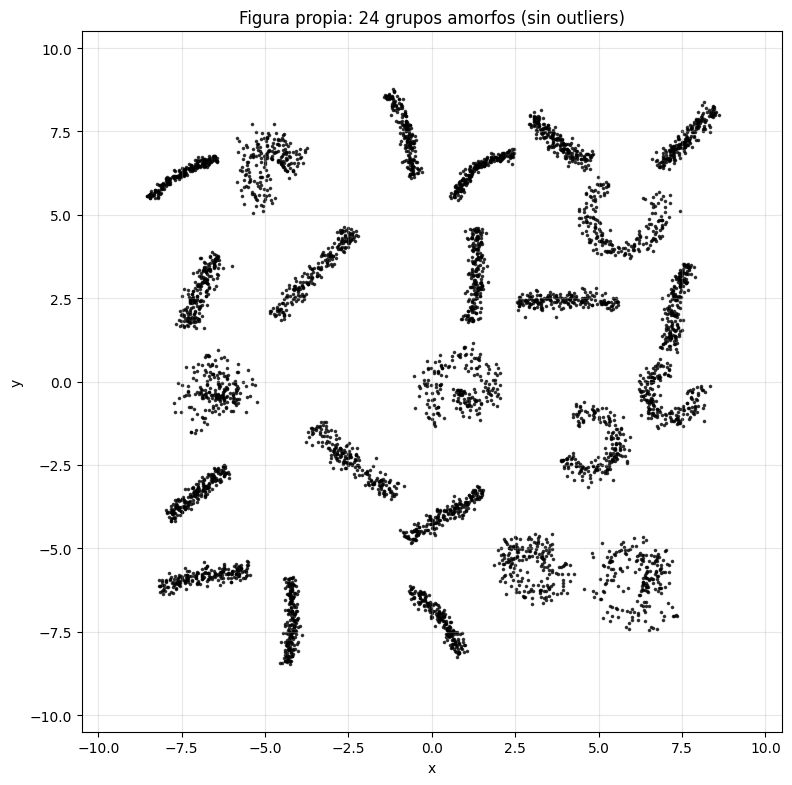

In [5]:

mask_grupos = ~is_outlier

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(X[mask_grupos, 0], X[mask_grupos, 1], s=2.5, c="black", alpha=0.7)
ax.set_xlim(-10.5, 10.5)
ax.set_ylim(-10.5, 10.5)
ax.set_title(f"Figura propia: {N_GRUPOS} grupos amorfos (sin outliers)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")
ax.set_facecolor("white")
plt.tight_layout()
plt.show()


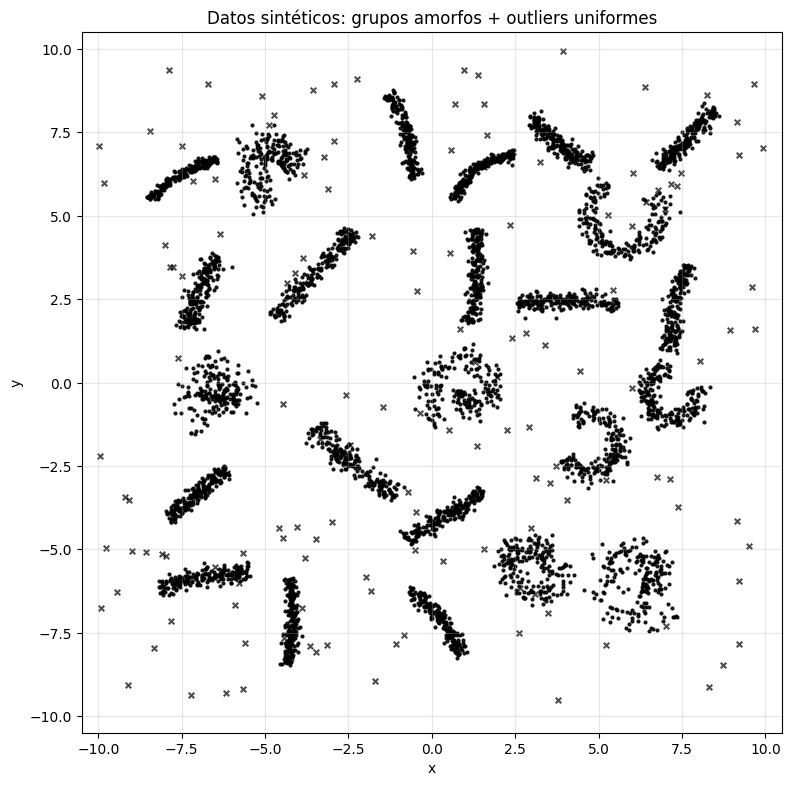

In [6]:

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(X[~is_outlier, 0], X[~is_outlier, 1], s=4, c="black", alpha=0.85)
ax.scatter(
    X[is_outlier, 0], X[is_outlier, 1],
    s=16, c="black", marker="x", alpha=0.7,
)

ax.set_xlim(-10.5, 10.5)
ax.set_ylim(-10.5, 10.5)
ax.set_title("Datos sintéticos: grupos amorfos + outliers uniformes")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()


Se observa que:
- Cada ejecución genera **≥ 20 trazos amorfos distintos**, sin solaparse (la semilla impresa permite repetir una figura concreta si hace falta).
- Los **outliers** se agregan de forma uniforme en el plano.


## 5. Escalamiento

Escalamos con `StandardScaler` porque DBSCAN usa distancias.


In [7]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## 6. Análisis exploratorio: gráfico de k-distancia

Fijamos **MinPts = 5**. Buscamos el **codo** en la curva de k-distancia para elegir `eps`.


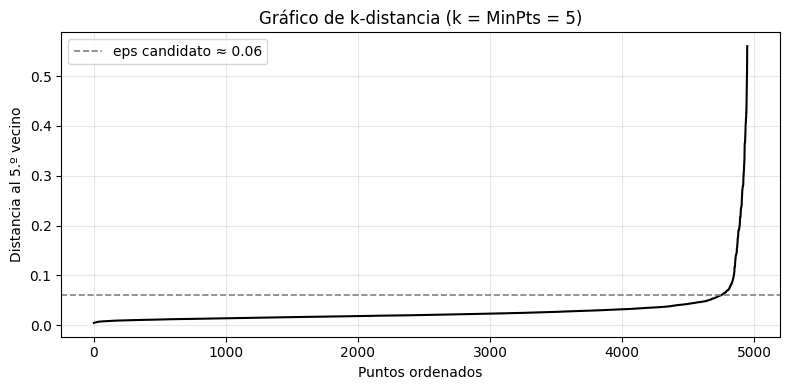

Percentiles de la k-distancia:
  p50: 0.020
  p70: 0.026
  p80: 0.031
  p85: 0.035
  p90: 0.041
  p95: 0.054


In [8]:

MIN_PTS = 5

nn = NearestNeighbors(n_neighbors=MIN_PTS)
nn.fit(X_scaled)
dists, _ = nn.kneighbors(X_scaled)
k_dists = np.sort(dists[:, -1])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_dists, color="black")
ax.set_title(f"Gráfico de k-distancia (k = MinPts = {MIN_PTS})")
ax.set_xlabel("Puntos ordenados")
ax.set_ylabel(f"Distancia al {MIN_PTS}.º vecino")
ax.axhline(0.06, color="gray", linestyle="--", linewidth=1.2, label="eps candidato ≈ 0.06")
ax.legend()
plt.tight_layout()
plt.show()

print("Percentiles de la k-distancia:")
for p in [50, 70, 80, 85, 90, 95]:
    print(f"  p{p}: {np.percentile(k_dists, p):.3f}")


La curva se mantiene baja en los puntos de los grupos y sube al final (outliers). El codo está cerca de **eps ≈ 0.06**.


## 7. Aplicación de DBSCAN

In [9]:

EPS = 0.06

db = DBSCAN(eps=EPS, min_samples=MIN_PTS)
y_pred = db.fit_predict(X_scaled)

n_clusters = len(set(y_pred)) - (1 if -1 in y_pred else 0)
n_noise = int(np.sum(y_pred == -1))

print(f"eps = {EPS}, MinPts = {MIN_PTS}")
print(f"Clústeres encontrados: {n_clusters}")
print(f"Puntos marcados como ruido: {n_noise} ({100 * n_noise / len(y_pred):.1f}%)")


eps = 0.06, MinPts = 5
Clústeres encontrados: 25
Puntos marcados como ruido: 128 (2.6%)


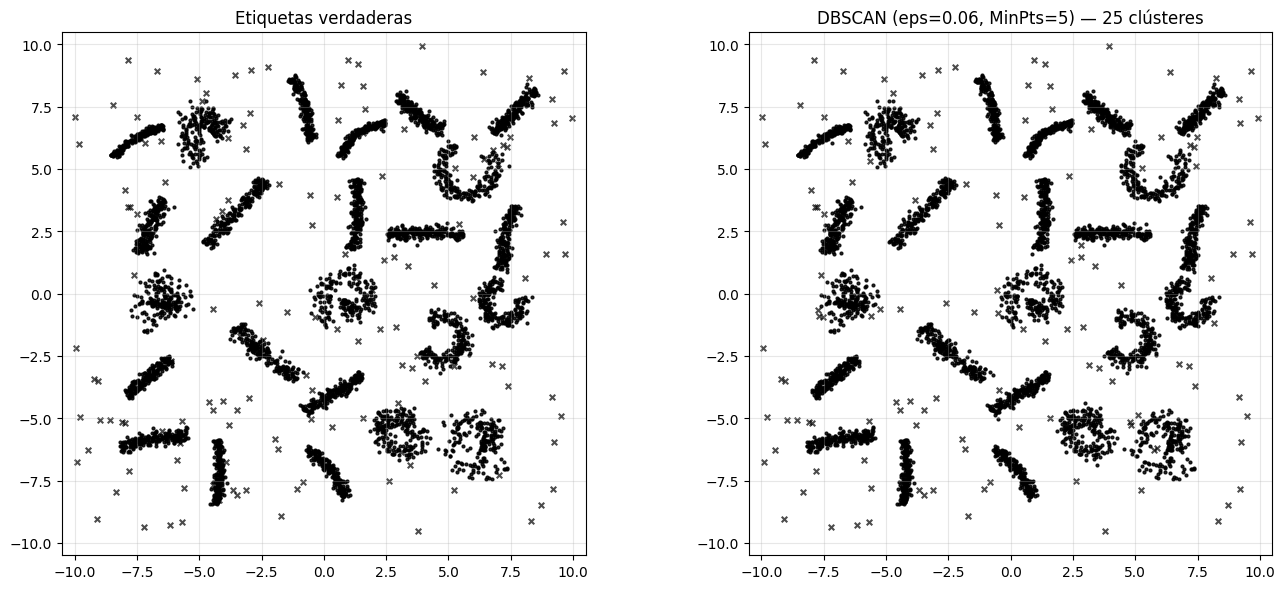

In [10]:

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.scatter(X[~is_outlier, 0], X[~is_outlier, 1], s=4, c="black", alpha=0.85)
ax.scatter(X[is_outlier, 0], X[is_outlier, 1], s=16, c="black", marker="x", alpha=0.7)
ax.set_title("Etiquetas verdaderas")
ax.set_xlim(-10.5, 10.5)
ax.set_ylim(-10.5, 10.5)
ax.set_aspect("equal")

ax = axes[1]
mask_noise = y_pred == -1
ax.scatter(X[~mask_noise, 0], X[~mask_noise, 1], s=4, c="black", alpha=0.85)
ax.scatter(X[mask_noise, 0], X[mask_noise, 1], s=16, c="black", marker="x", alpha=0.7)
ax.set_title(f"DBSCAN (eps={EPS}, MinPts={MIN_PTS}) — {n_clusters} clústeres")
ax.set_xlim(-10.5, 10.5)
ax.set_ylim(-10.5, 10.5)
ax.set_aspect("equal")

plt.tight_layout()
plt.show()


## 8. Evaluación de desempeño (dos métodos)

1. **Silhouette Score** (interna): solo puntos **no ruido**.
2. **Adjusted Rand Index — ARI** (externa): acuerdo con etiquetas verdaderas (outliers = `-1`).

Guías: [Clustering Metrics](https://scikit-learn.org/stable/modules/classes.html#clustering-metrics) y [Clustering performance evaluation](https://scikit-learn.org/stable/modules/clustering.html#clustering-performance-evaluation).


In [11]:

mask_clustered = y_pred != -1
if mask_clustered.sum() > n_clusters and n_clusters >= 2:
    sil = silhouette_score(X_scaled[mask_clustered], y_pred[mask_clustered])
else:
    sil = float("nan")

ari = adjusted_rand_score(y_true, y_pred)

print(f"Silhouette Score: {sil:.3f}")
print(f"Adjusted Rand Index (ARI): {ari:.3f}")


Silhouette Score: 0.610
Adjusted Rand Index (ARI): 0.980


## 9. Exploración de `eps` alrededor del codo

In [12]:

resultados = []
for eps_try in [0.05, 0.06, 0.07, 0.08, 0.09, 0.10]:
    pred = DBSCAN(eps=eps_try, min_samples=MIN_PTS).fit_predict(X_scaled)
    n_cl = len(set(pred)) - (1 if -1 in pred else 0)
    n_ruido = int(np.sum(pred == -1))
    m = pred != -1
    sil_t = (
        silhouette_score(X_scaled[m], pred[m])
        if (m.sum() > n_cl and n_cl >= 2)
        else np.nan
    )
    resultados.append({
        "eps": eps_try,
        "n_clusters": n_cl,
        "n_ruido": n_ruido,
        "silhouette": sil_t,
        "ARI": adjusted_rand_score(y_true, pred),
    })

pd.DataFrame(resultados).round(3)


,eps,n_clusters,n_ruido,silhouette,ARI
0,0.05,27,175,0.586,0.961
1,0.06,25,128,0.610,0.980
2,0.07,24,110,0.624,0.983
3,0.08,22,99,0.581,0.903
4,0.09,21,92,0.563,0.833
5,0.10,20,91,0.543,0.802


## 10. Conclusiones

1. Generamos una **figura aleatoria** con **24 trazos amorfos** sin solapamiento, más outliers uniformes.
2. Con el gráfico de **k-distancia** (MinPts = 5) elegimos **eps ≈ 0.06**.
3. DBSCAN recupera esos grupos y marca outliers como ruido (`-1`).
4. Evaluamos con **Silhouette** y **ARI**.
5. Un `eps` muy pequeño fragmenta; uno muy grande fusiona. Por eso se combina el codo con una pequeña tabla de prueba.
